# GEMMA × ReDLat — tutorial para leer tu output de exposoma

Este notebook es el tutorial oficial para trabajar con los **outputs de
exposoma que GEMMA genera para ReDLat**: el CSV `point_exposome_wide.csv`
que BrainLat te entrega con el exposoma ambiental/social estimado alrededor
de la residencia de cada participante de tu cohorte.

Es un **tutorial reutilizable y autocontenido**: no depende del código
interno de GEMMA (que es privado) ni de ningún archivo del repositorio --
solo de `pandas`/`numpy`/`matplotlib` y del CSV que recibís. La idea es que
sirva como guía cada vez que BrainLat te entregue una descarga nueva, sin
importar qué ronda de datos esté vigente.

Acá vas a encontrar:

1. Qué es GEMMA y su relación con ReDLat.
2. Cómo está organizado tu output (`point_exposome_wide.csv`).
3. Qué significa el radio de búsqueda que elegís para cada indicador.
4. Un tutorial práctico con pandas: cargar, inspeccionar, filtrar y comparar.

Todos los ejemplos de código corren sobre un **DataFrame sintético**
(participantes `EJ001`/`EJ002`/`EJ003`, inventados) con el mismo esquema de
columnas que tu CSV real -- reemplazá `example_wide` por
`pd.read_csv("point_exposome_wide.csv", dtype={"record_id": str})` para
trabajar con tus datos.


## 1. Qué es GEMMA (y su relación con ReDLat)

**GEMMA** (*Global Exposome Modeling, Mapping & Analytics*) es la plataforma
de BrainLat que arma, documenta y publica indicadores del exposoma urbano
(ambientales, sociales, de infraestructura y de contexto de salud) a escala
sub-ciudad, ciudad por ciudad en Latinoamérica y otras regiones.

Se construyó específicamente para dar soporte de datos de exposición
ambiental a **ReDLat** (*The Multi-Partner Consortium to Expand Dementia
Research in Latin America*): cuando un equipo de ReDLat necesita saber a qué
contaminación del aire, calor, ruido, entorno social o infraestructura
estuvo expuesto un participante según su lugar de residencia, GEMMA es la
fuente. El CSV que acompaña este tutorial es exactamente ese cruce: el
código postal/dirección de cada participante, geocodificado, y el exposoma
de GEMMA extraído alrededor de ese punto.

**GEMMA hoy** (alcance de la plataforma, no de esta entrega puntual):
cobertura activa en Sudamérica, Norteamérica y Europa, con ciudades como
Bogotá, Buenos Aires, Ciudad de México, Lima, Medellín, Santiago, Cataluña,
País Vasco y Barcelona ya publicadas -- ver la captura abajo, que es del
explorador interactivo real (mapa mundi pixel-art, click para entrar a cada
ciudad; es una imagen, no un demo en vivo).


![Explorador interactivo de GEMMA](assets/gemma_demo_worldmap.png)


## 2. Tu output de GEMMA: cómo está organizado

El archivo que GEMMA te entrega para tu cohorte de ReDLat
(`point_exposome_wide.csv`) tiene **una fila por participante** (`record_id`)
y **no incluye** latitud, longitud, dirección ni variables clínicas -- solo
`record_id` para que lo cruces con tu propio roster.

Las columnas de exposoma siguen dos patrones:

- **Indicadores raster** (PM2.5, luz nocturna, NO₂, calor, lluvia, viento...):
  una columna por radio ofrecido, `<indicador>_r<radio>m`, más su gemela
  `<indicador>_r<radio>m_flag` con la calidad de esa celda.
- **Indicadores administrativos** (nivel socioeconómico, caminabilidad,
  acceso a salud...): ya vienen agregados a la unidad administrativa que
  contiene al participante, así que **no llevan sufijo de radio** -- una
  sola columna `<indicador>` + `<indicador>_flag`.

Armemos un DataFrame de ejemplo con el mismo esquema para ver esto en
código. **Estos participantes son inventados** -- ningún `record_id`, valor
ni ubicación corresponde a datos reales.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 12)


In [2]:
# Participantes de ejemplo -- inventados, solo para mostrar el esquema.
example_wide = pd.DataFrame([
    {
        "record_id": "EJ001", "geocode_precision": "admin_centroid", "country_code": "CL",
        "out_of_coverage_reason": None,
        "pm25_r0m": 21.4, "pm25_r0m_flag": "sub_observation",
        "pm25_r300m": 21.3, "pm25_r300m_flag": "sub_observation",
        "pm25_r500m": 21.1, "pm25_r500m_flag": "sub_observation",
        "pm25_r1000m": 20.8, "pm25_r1000m_flag": "ok",
        "alan_r0m": 42.1, "alan_r0m_flag": "ok",
        "alan_r300m": 39.8, "alan_r300m_flag": "ok",
        "alan_r500m": 37.2, "alan_r500m_flag": "ok",
        "alan_r1000m": 33.0, "alan_r1000m_flag": "ok",
        "nse": 0.62, "nse_flag": "ok",
        "walkability": 71.0, "walkability_flag": "ok",
    },
    {
        "record_id": "EJ002", "geocode_precision": "admin_centroid", "country_code": "CO",
        "out_of_coverage_reason": None,
        "pm25_r0m": 14.9, "pm25_r0m_flag": "sub_observation",
        "pm25_r300m": 14.9, "pm25_r300m_flag": "sub_observation",
        "pm25_r500m": 14.9, "pm25_r500m_flag": "sub_observation",
        "pm25_r1000m": 15.0, "pm25_r1000m_flag": "ok",
        "alan_r0m": 18.6, "alan_r0m_flag": "ok",
        "alan_r300m": 17.9, "alan_r300m_flag": "ok",
        "alan_r500m": 17.1, "alan_r500m_flag": "ok",
        "alan_r1000m": 15.5, "alan_r1000m_flag": "ok",
        "nse": -0.31, "nse_flag": "ok",
        "walkability": 58.0, "walkability_flag": "ok",
    },
    {
        "record_id": "EJ003", "geocode_precision": "unresolved", "country_code": "AR",
        "out_of_coverage_reason": "geocoding_unresolved",
        "pm25_r0m": None, "pm25_r0m_flag": None,
        "pm25_r300m": None, "pm25_r300m_flag": None,
        "pm25_r500m": None, "pm25_r500m_flag": None,
        "pm25_r1000m": None, "pm25_r1000m_flag": None,
        "alan_r0m": None, "alan_r0m_flag": None,
        "alan_r300m": None, "alan_r300m_flag": None,
        "alan_r500m": None, "alan_r500m_flag": None,
        "alan_r1000m": None, "alan_r1000m_flag": None,
        "nse": None, "nse_flag": None,
        "walkability": None, "walkability_flag": None,
    },
])

example_wide


,record_id,geocode_precision,country_code,out_of_coverage_reason,pm25_r0m,pm25_r0m_flag,...,alan_r1000m,alan_r1000m_flag,nse,nse_flag,walkability,walkability_flag
0,EJ001,admin_centroid,CL,NaN,21.4,sub_observation,...,33.0,ok,0.62,ok,71.0,ok
1,EJ002,admin_centroid,CO,NaN,14.9,sub_observation,...,15.5,ok,-0.31,ok,58.0,ok
2,EJ003,unresolved,AR,geocoding_unresolved,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# La forma practica de distinguir columnas raster de administrativas: una
# regex sobre el nombre.
RADIUS_COLUMN = re.compile(r"^(?P<indicador>.+)_r(?P<radio>\d+)m$")

raster_columns = [c for c in example_wide.columns if RADIUS_COLUMN.match(c) and not c.endswith("_flag")]
context_columns = {"record_id", "geocode_precision", "country_code", "out_of_coverage_reason"}
admin_columns = [
    c for c in example_wide.columns
    if c not in context_columns and not c.endswith("_flag") and not RADIUS_COLUMN.match(c)
]
print("Columnas raster (con radio):", raster_columns)
print("Columnas administrativas (sin radio):", admin_columns)


Columnas raster (con radio): ['pm25_r0m', 'pm25_r300m', 'pm25_r500m', 'pm25_r1000m', 'alan_r0m', 'alan_r300m', 'alan_r500m', 'alan_r1000m']
Columnas administrativas (sin radio): ['nse', 'walkability']


## 3. Qué significa cada radio

Un indicador de exposoma no tiene un valor "en un punto": tiene un valor
sobre una región de soporte (el píxel satelital, la celda de reanálisis, la
unidad administrativa). Pedirle a un dato de soporte grande que responda con
soporte de punto exacto es el *problema de cambio de soporte* -- BrainLat te
puede compartir la metodología completa (estimadores, incertidumbre) junto
con tu entrega si la necesitás.

Acá la versión corta. Para un punto `x`, un indicador y un radio `r`, lo que
se entrega es **el promedio del indicador sobre el disco de radio `r`
alrededor de `x`** (`r=0` = la celda que contiene al punto -- el número
primario, sin modelo).

| radio | qué representa |
|---|---|
| `0` m | la celda/unidad que contiene al participante -- el valor publicado, sin buffer |
| `300` m | estándar de acceso a área verde de la OMS |
| `500` m | "distancia caminable", ~5-10 min a pie |
| `1000` m | escala de barrio; el mínimo resoluble para PM2.5 (grilla ~1.1 km) |

**La regla clave**: un radio menor a la resolución real de observación del
indicador no promedia nada -- devuelve el mismo valor de la celda
contenedora, marcado `sub_observation` en vez de `ok`. Se entrega igual (para
comparabilidad entre indicadores), pero no hay que leerlo como si describiera
variación real a esa escala.


In [4]:
# Ejemplo con el DataFrame sintetico: PM2.5 (grilla ~1 km) queda
# sub_observation en 0/300/500m -- el radio no agrega nada nuevo hasta 1000m.
# ALAN (grilla mas fina) ya resuelve desde 300m.
participant = example_wide.iloc[0]
for indicador in ("pm25", "alan"):
    print(f"--- {indicador} ---")
    for radio in (0, 300, 500, 1000):
        valor = participant[f"{indicador}_r{radio}m"]
        flag = participant[f"{indicador}_r{radio}m_flag"]
        print(f"  r={radio:>4}m  valor={valor:>6}  flag={flag}")


--- pm25 ---
  r=   0m  valor=  21.4  flag=sub_observation
  r= 300m  valor=  21.3  flag=sub_observation
  r= 500m  valor=  21.1  flag=sub_observation
  r=1000m  valor=  20.8  flag=ok
--- alan ---
  r=   0m  valor=  42.1  flag=ok
  r= 300m  valor=  39.8  flag=ok
  r= 500m  valor=  37.2  flag=ok
  r=1000m  valor=  33.0  flag=ok


**Regla práctica**: para un indicador dado, usá el radio *más chico* que
aparezca marcado `ok` en la columna `_flag` -- un radio mayor marcado
`sub_observation` no agrega información real, solo repite el valor de la
celda.


## 4. Tutorial práctico con pandas

Todo lo que sigue corre sobre `example_wide` -- reemplazá `example_wide` por
`pd.read_csv("point_exposome_wide.csv", dtype={"record_id": str, "country_code": str})`
para trabajar tu CSV real. El `dtype` explícito importa: si no lo pasás,
pandas puede tratar `record_id` como número y romper IDs que empiecen con
letras.


### 4.1 Cargar e inspeccionar


In [5]:
# df = pd.read_csv("point_exposome_wide.csv", dtype={"record_id": str, "country_code": str})
df = example_wide.copy()

print(f"{len(df)} participantes, {df.shape[1]} columnas")
print()
print("Columnas de contexto:", sorted(context_columns))
print()
print("Indicadores disponibles:", sorted({RADIUS_COLUMN.match(c).group("indicador")
      for c in df.columns if RADIUS_COLUMN.match(c) and not c.endswith("_flag")}
      | set(admin_columns)))


3 participantes, 24 columnas

Columnas de contexto: ['country_code', 'geocode_precision', 'out_of_coverage_reason', 'record_id']

Indicadores disponibles: ['alan', 'nse', 'pm25', 'walkability']


### 4.2 Filtrar un indicador a un radio, descartando `sub_observation`


In [6]:
def valores_confiables(df: pd.DataFrame, indicador: str, radio: int) -> pd.DataFrame:
    valor_col, flag_col = f"{indicador}_r{radio}m", f"{indicador}_r{radio}m_flag"
    subset = df[["record_id", valor_col, flag_col]].dropna(subset=[valor_col])
    return subset[subset[flag_col] == "ok"]

valores_confiables(df, "pm25", 1000)


,record_id,pm25_r1000m,pm25_r1000m_flag
0,EJ001,20.8,ok
1,EJ002,15.0,ok


### 4.3 Comparar un indicador entre participantes


In [7]:
comparacion = df.set_index("record_id")[["pm25_r1000m", "alan_r1000m", "nse", "walkability"]]
comparacion


,pm25_r1000m,alan_r1000m,nse,walkability
record_id,,,,
EJ001,20.8,33.0,0.62,71.0
EJ002,15.0,15.5,-0.31,58.0
EJ003,NaN,NaN,NaN,NaN


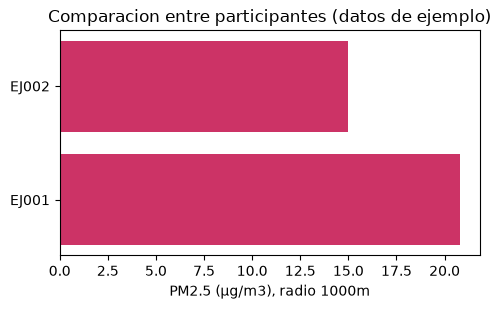

In [8]:
# Un grafico rapido de comparacion (matplotlib puro, sin estilos externos).
visible = comparacion.dropna()
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.barh(visible.index, visible["pm25_r1000m"], color="#CC3366")
ax.set_xlabel("PM2.5 (µg/m3), radio 1000m")
ax.set_title("Comparacion entre participantes (datos de ejemplo)")
fig.tight_layout()
plt.show()


### 4.4 De ancho a largo (para quien prefiere trabajar en formato largo)


In [9]:
radio_cols = [c for c in df.columns if RADIUS_COLUMN.match(c) and not c.endswith("_flag")]
largo = df.melt(id_vars="record_id", value_vars=radio_cols, var_name="columna", value_name="valor").dropna()
largo[["indicador", "radio_m"]] = largo["columna"].str.extract(r"^(.+)_r(\d+)m$")
largo = largo.drop(columns="columna")
largo.head(10)


,record_id,valor,indicador,radio_m
0,EJ001,21.4,pm25,0
1,EJ002,14.9,pm25,0
3,EJ001,21.3,pm25,300
4,EJ002,14.9,pm25,300
6,EJ001,21.1,pm25,500
7,EJ002,14.9,pm25,500
9,EJ001,20.8,pm25,1000
10,EJ002,15.0,pm25,1000
12,EJ001,42.1,alan,0
13,EJ002,18.6,alan,0


## 5. Preguntas frecuentes

- **¿Por qué mi participante no tiene ningún valor?** `geocode_precision =
  unresolved` significa que no lo pudimos ubicar a un punto -- nunca se
  inventa una ubicación. `out_of_coverage_reason` dice por qué: falta
  mejorar la geocodificación, o BrainLat todavía no publica un estudio en
  esa ciudad.
- **¿`admin_centroid` es el domicilio real del participante?** No -- es el
  punto representativo de su unidad administrativa (comuna, distrito,
  localidad). Válido para indicadores marcados `ok` a esa resolución; nunca
  para leer un buffer de 0-300 m como exposición domiciliaria exacta.
- **¿Estos datos son frecuencia de enfermedad?** No -- describen exposición
  ambiental/social estimada por ubicación, no un desenlace clínico.
- **¿Cómo pido una actualización o más ciudades?** Escribile al equipo de
  BrainLat/GEMMA que te compartió este archivo.
